In [ ]:
# !pip3 install pandas numpy matplotlib

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8,5)

In [ ]:
trace = pd.read_csv("data-old/node_4_long_trace.csv")

trace.head()

,node_id,timestamp_usec,event,term,leader_id,value
0,4,85061357235,timeout,0,-1,0
1,4,85061357278,became_candidate,0,-1,0
2,4,85208816394,became_follower,2,0,0
3,4,85209053011,heartbeat,2,0,109552
4,4,85209342716,heartbeat,2,0,289712


In [6]:
trace = trace.sort_values("timestamp_usec").reset_index(drop=True)

# convert to seconds
trace["timestamp_sec"] = trace["timestamp_usec"] / 1e6

In [7]:
unstable_events = {
    "timeout",
    "became_candidate",
    "became_follower",
    "became_leader"
}

trace["unstable"] = trace["event"].isin(unstable_events)

In [8]:
WINDOW_SEC = 5

unstable_times = trace.loc[trace["unstable"], "timestamp_sec"].values

def near_unstable(t):
    return np.any(np.abs(unstable_times - t) < WINDOW_SEC)

heartbeats = trace[trace["event"] == "heartbeat"].copy()

heartbeats["near_unstable"] = heartbeats["timestamp_sec"].apply(near_unstable)

stable_heartbeats = heartbeats[~heartbeats["near_unstable"]].copy()

print("Total heartbeats:", len(heartbeats))
print("Stable heartbeats:", len(stable_heartbeats))

Total heartbeats: 104374
Stable heartbeats: 104339


In [14]:
stable_heartbeats["interval"] = stable_heartbeats["timestamp_sec"].diff()

intervals = stable_heartbeats["interval"].dropna()


intervals.describe()

count    104338.000000
mean          0.298143
std           0.469335
min           0.000079
25%           0.146504
50%           0.252754
75%           0.500340
max         138.422189
Name: interval, dtype: float64

In [18]:
# IQR-based outlier filtering
q1 = intervals.quantile(0.25)
q3 = intervals.quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

intervals = intervals[(intervals >= lower_bound) & (intervals <= upper_bound)]

print(f"Kept {len(intervals)} intervals after outlier filtering")
print(f"Bounds: [{lower_bound:.6f}, {upper_bound:.6f}]")

Kept 104299 intervals after outlier filtering
Bounds: [-0.384250, 1.031094]


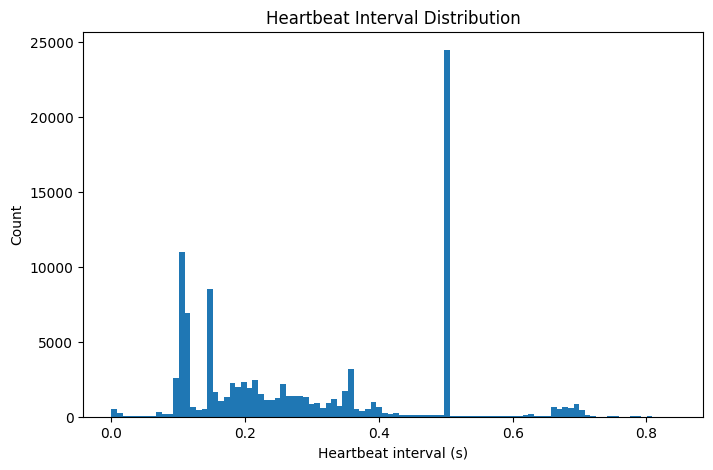

In [19]:
plt.hist(sorted(intervals), bins=100)
plt.xlabel("Heartbeat interval (s)")
plt.ylabel("Count")
plt.title("Heartbeat Interval Distribution")
plt.show()

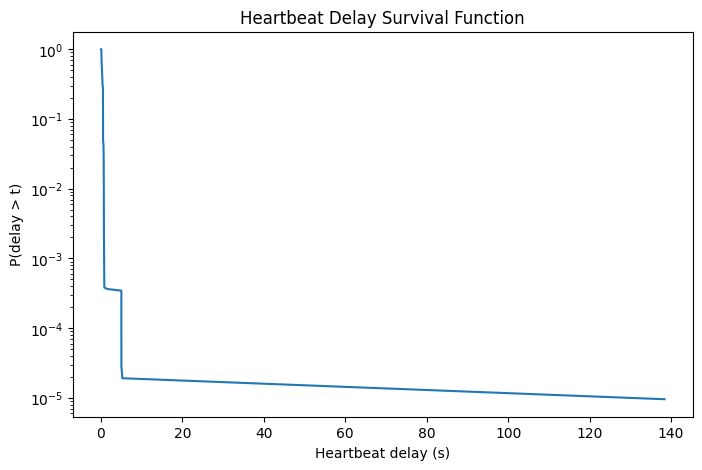

In [10]:
sorted_intervals = np.sort(intervals.values)

survival = 1.0 - np.arange(len(sorted_intervals)) / len(sorted_intervals)

plt.semilogy(sorted_intervals, survival)
plt.xlabel("Heartbeat delay (s)")
plt.ylabel("P(delay > t)")
plt.title("Heartbeat Delay Survival Function")
plt.show()